In [9]:
include("MiniCollectiveSpins.jl")
include("Functions_time_evol_decay.jl")
using PyPlot
using Statistics
using JLD2

### Define the system

In [10]:
# Nbr of particles
N_list = [4]#[2:2:10;]
r = 5
d0_lb = 5e-10 # Minimum distance between the atoms (lower boundary) in m
λ = 421e-9
d0_lb = d0_lb / λ
window_t, window_var = 2, 4
threshold_box = 1e-5; # Time over which the boxes are computed

# Plots of the time evolution

In [11]:
fig, ax = subplots()
list_t_N, popup_t_N, nbr_error_t_N, sol_t_N = [], [], [], []

for (i, N) in enumerate(N_list)
    line = []
    @load "solutions/sol_N_$(N)_r_$(r).jld2" sol_tasks
    list_t, popup_t, nbr_error, sol_t =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
    push!(list_t_N, list_t), push!(popup_t_N, popup_t), push!(nbr_error_t_N, nbr_error), push!(sol_t_N, sol_t)
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if line == []
                line, = ax.plot(list_t[j], popup_t[j], label="N=$(N_list[i])") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t[j], popup_t[j], color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  N_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N_list, r = $r, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

┌ Warning: Opening file with JLD2.MmapIO failed, falling back to IOStream
└ @ JLD2 C:\Users\Joschka\.julia\packages\JLD2\WDhXU\src\JLD2.jl:162


SystemError: SystemError: opening file "solutions/sol_N_4_r_5.jld2": No such file or directory

# Plot the evolutions that didn't work

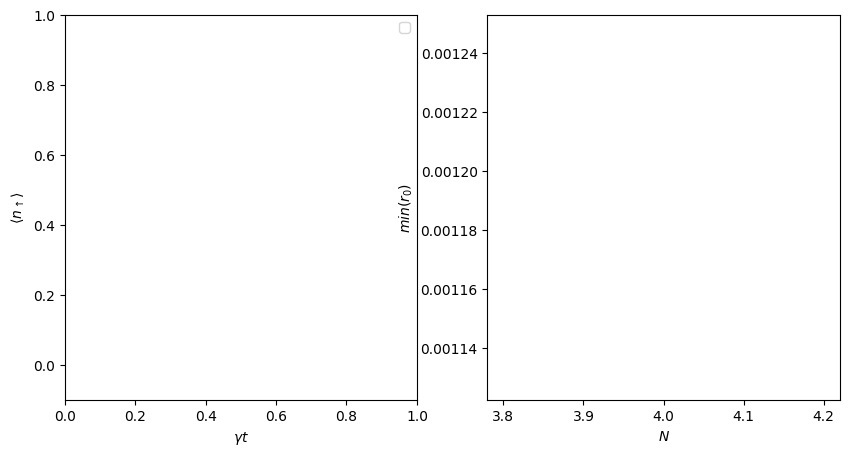

In [12]:
close("all")
fig, axes = subplots(1, 2, figsize=(10, 5))
for i in 1:length(popup_t_N)
    line = []
    for j in 1:length(popup_t_N[i])
        @load "../SS/r0/r0_N_$(N_list[i])_r_$j.jdl2" r0 L
        if j ∈ nbr_error_t_N[i]
            if line == []
                line, = axes[1].plot(list_t_N[i][j], popup_t_N[i][j], label="N=$(N_list[i])")
            else
                axes[1].plot(list_t_N[i][j], popup_t_N[i][j], color=line.get_color())
            end
            axes[2].scatter(N_list[i], min_r0(r0), color ="r")
        else
            axes[2].scatter(N_list[i], min_r0(r0), color ="b")
        end
    end
end


axes[1].set_xlabel(L"$\gamma t$")
axes[1].set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
axes[1].legend()
axes[1].set_ylim(-0.1, 1)

axes[2].hlines(d0_lb, N_list[1], N_list[end])
axes[2].set_xlabel(L"N")
axes[2].set_ylabel(L"min(r_0)")
pygui(false); gcf();
# pygui(true); show()

# Timestep 

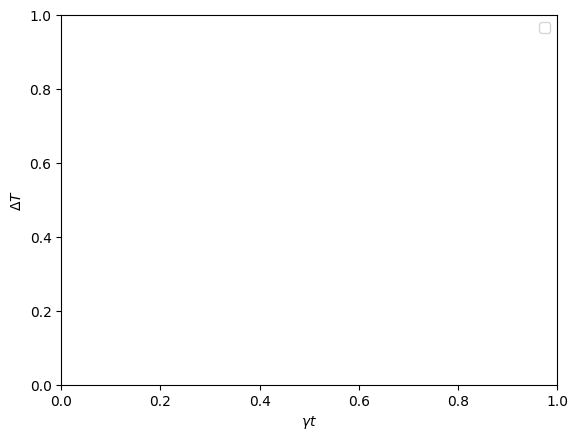

In [13]:
close("all")
fig, ax = subplots()
for i in 1:length(popup_t_N)
    line = []
    for j in 1:length(popup_t_N[i])
        T = list_t_N[i][j]
        if j == 1
            line, = ax.plot(T[1:end-1], T[2:end]-T[1:end-1], label=N_list[i])
        else
            ax.plot(T[1:end-1], T[2:end]-T[1:end-1], color=line.get_color())
        end
    end
end


ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\Delta T$")
ax.legend()
pygui(false); gcf();
# pygui(true); show()

# Evolution of individual atoms

In [14]:
close("all")
fig, ax = subplots()

for (i, N) = enumerate(N_list)
    line = []
    @load "solutions/sol_N_$(N)_r_$(r).jld2" sol_tasks
    list_t, popup_t, nbr_error, sol_t =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]

    # Check if the SS was found
    @load "../SS/solutions/sol_N_$(N)_r_$r.jld2" sol_tasks
    nbr_error_SS =  vcat([s[3] for s in sol_tasks]...)
    
    for j = 1:length(list_t)
        if (j ∉ nbr_error_t_N[i]) && (j ∉ nbr_error_t_N[i])
            # ax.plot(list_t[j], popup_t[j], label="Sum")
            for n in 1:N
                if line == []
                    line, = ax.plot(list_t[j], real([sol_t[j][t][n] for t in 1:length(list_t[j])]), label="$N")
                else
                    ax.plot(list_t[j], real([sol_t[j][t][n] for t in 1:length(list_t[j])]), color = line.get_color())
                end
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle n_{\uparrow} \rangle $")
# ax.set_ylim(-0.002, 0.005)
ax.legend()

suptitle("N = $N_list, r = $r, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

┌ Warning: Opening file with JLD2.MmapIO failed, falling back to IOStream
└ @ JLD2 C:\Users\Joschka\.julia\packages\JLD2\WDhXU\src\JLD2.jl:162


SystemError: SystemError: opening file "solutions/sol_N_4_r_5.jld2": No such file or directory

# Initial slope

In [15]:
# Prepare the wrapper
const N_FUNCS = length(N_list)  # Total function nbr
const functs = Vector{Function}(undef, N_FUNCS)

for (i, N) in enumerate(N_list)
    libpath ="libs/liballfuncs_$N.dll"
    functs[i] = load_f("diffeqf", libpath)
end

In [16]:
stationnary_state(2, 10, 10)

2, 10, 10


9-element Vector{ComplexF64}:
  0.0010691282220470534 + 0.0im
   0.001038438180833466 + 0.0im
   0.029265870178838433 + 0.008787317227929824im
   0.030317279529102143 - 0.0019959647035115344im
  0.0009014754208043888 + 0.0003138780309550851im
 -2.1906887550219785e-5 + 0.0002736490051816411im
   7.467329175147893e-5 + 0.00026433950952854im
   8.150563255357781e-5 + 1.609720876359123e-23im
   1.724373524362163e-5 + 0.009010510967387081im